In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier

In [2]:
# loading dataset

df = pd.read_csv('Credit_Card_Default.csv')

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month

In [3]:
# basic info

print(df.info())
print(df.columns.to_list())
print(df.describe())



<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [4]:
# checking missing values

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values
})

missing_table = missing_table[
    missing_table["Missing Values"] > 0
]

if len(missing_table) == 0:
    print("No missing values found.")
else:
    display(missing_table)

No missing values found.


In [5]:
# removing duplicate records
duplicate_count = df.duplicated().sum()

print("Duplicate Records:", duplicate_count)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Duplicate Records: 0
Shape after removing duplicates: (30000, 25)


In [6]:
# removing id column

df.drop('ID', axis=1, inplace=True)

In [7]:
# renaming target variable
df.rename(columns={'default.payment.next.month': 'target'}, inplace=True)

print("target column: target")

target column: target


In [8]:
# cleaning categorical variables

df["EDUCATION"] = df["EDUCATION"].replace({5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

print("Categorical codes cleaned.")

Categorical codes cleaned.


In [9]:
# target distribution

print(df["target"].value_counts())

print("\nTarget Percentage:")
print(df["target"].value_counts(normalize=True) .mul(100) .round(2)
)

target
0    23364
1     6636
Name: count, dtype: int64

Target Percentage:
target
0    77.88
1    22.12
Name: proportion, dtype: float64


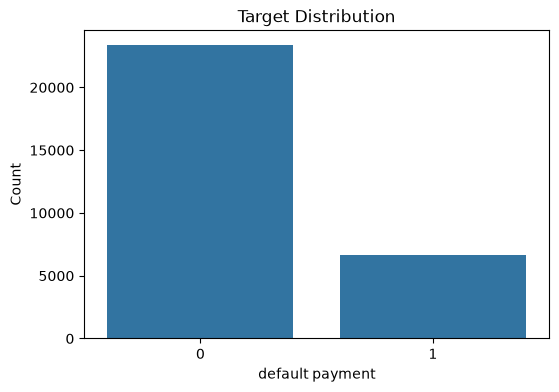

In [10]:
# target distribution plotting

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Target Distribution')
plt.xlabel("default payment")
plt.ylabel("Count")
plt.show()

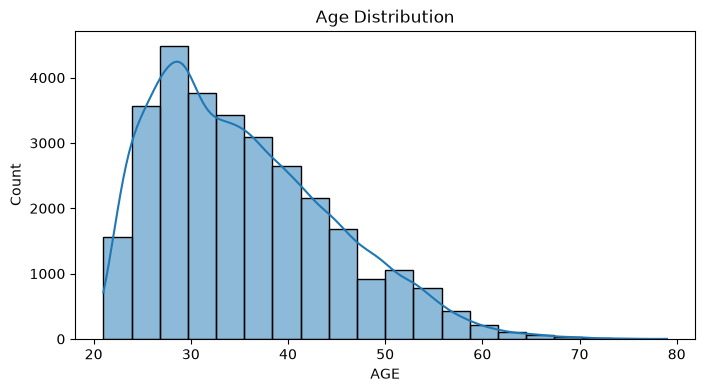

In [11]:
# EDA 

# age distribution

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='AGE', bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

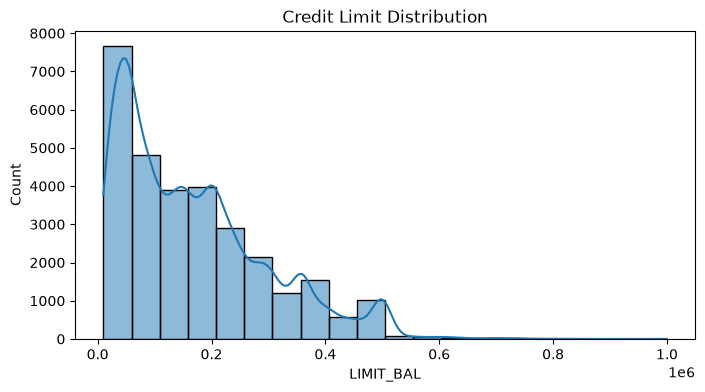

In [12]:
# Chart for credit limit distribution

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='LIMIT_BAL', bins=20, kde=True)
plt.title('Credit Limit Distribution')
plt.show()

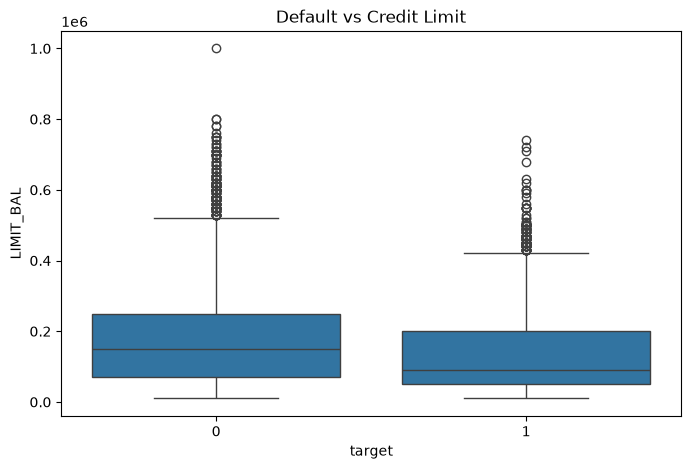

In [13]:
# default vs credit limit

plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='LIMIT_BAL', data=df)
plt.title('Default vs Credit Limit')
plt.show()

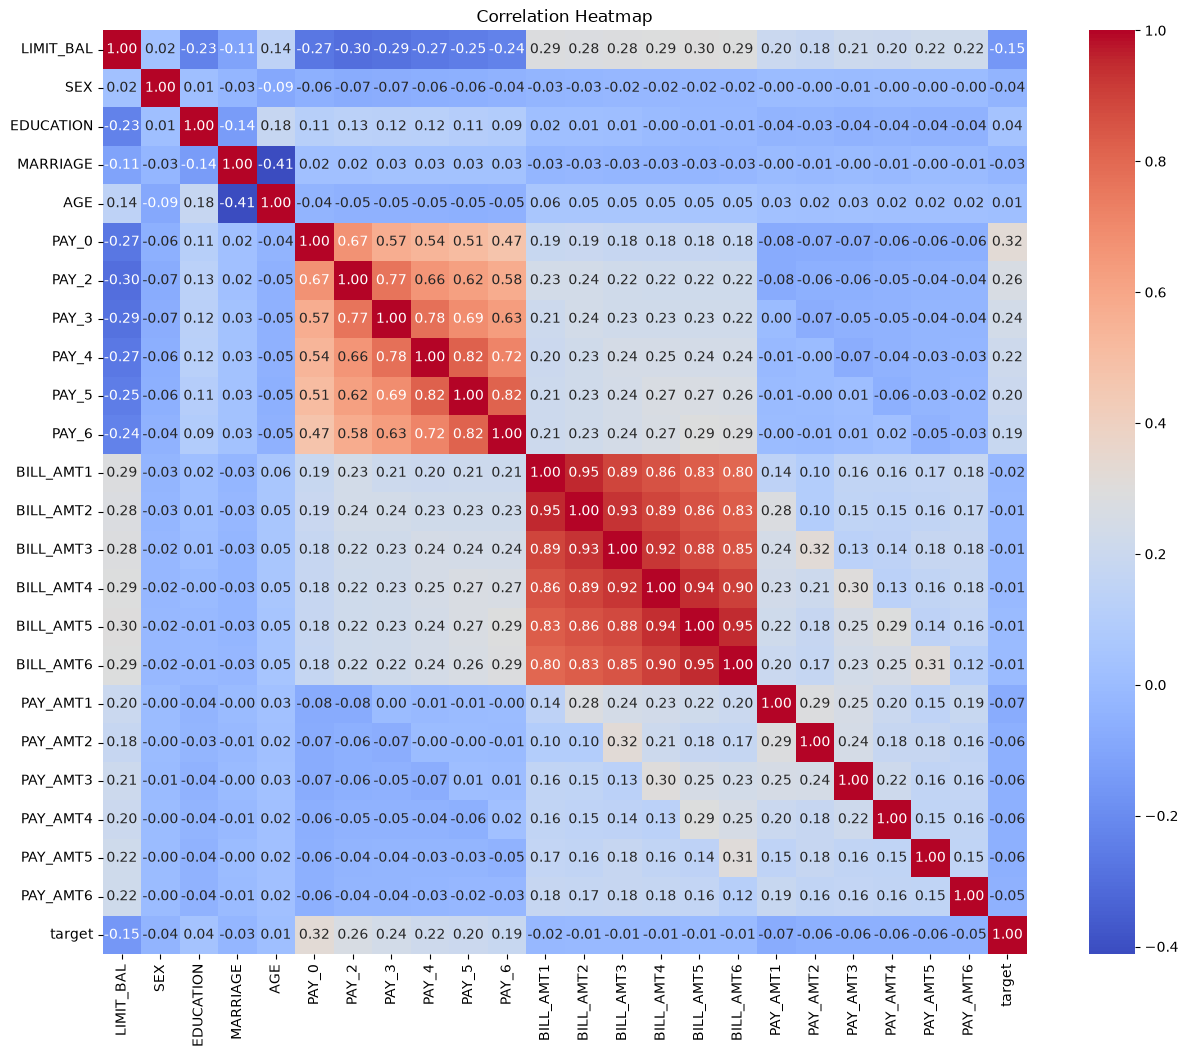

In [14]:
# correlation heatmap

plt.figure(figsize=(16, 12))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)  
plt.title('Correlation Heatmap')
plt.show()

In [15]:
# feature and target distribution

X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (30000, 23)
Target shape: (30000,)


In [16]:
# train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [17]:
# Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print("before SMOTE", y_train.value_counts())
print("after SMOTE", y_train_smote.value_counts())



before SMOTE target
0    18691
1     5309
Name: count, dtype: int64
after SMOTE target
0    18691
1    18691
Name: count, dtype: int64


In [19]:
# developing models

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42, C=1.0, solver='liblinear'),
    "KNN": KNeighborsClassifier(n_neighbors=7, weights='distance'),
    "Naive Bayes": GaussianNB(),
    "Linear SVM": LinearSVC(C=1.0, max_iter = 3000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, min_samples_split=10),
    "Extra Trees": ExtraTreesClassifier(random_state=42, n_estimators=50, max_depth=10, min_samples_split=10, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=50, learning_rate=0.05, max_depth=3),
    "AdaBoost": AdaBoostClassifier(random_state=42, n_estimators=50, learning_rate=0.05),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42, max_iter=50, learning_rate=0.05, max_leaf_nodes=15),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "XGBoost": XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1)
}

In [20]:
# model training and evaluation

results = []
trained_models = {}

for name, model in models.items():

    print(f"Training: {name}")

    try:
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_prob = model.decision_function(X_test)
        else:
            y_prob = None

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        if y_prob is not None:
            roc_auc = roc_auc_score(y_test, y_prob)
        else:
            roc_auc = 0

        results.append([
            name,
            accuracy,
            precision,
            recall,
            f1,
            roc_auc
        ])

        trained_models[name] = model

        print(
            f"✓ {name} completed | "
            f"Accuracy: {accuracy:.4f} | "
            f"ROC-AUC: {roc_auc:.4f}"
        )

    except Exception as e:
        print(f"✗ {name} skipped: {e}")

Training: Logistic Regression
✓ Logistic Regression completed | Accuracy: 0.7788 | ROC-AUC: 0.6340
Training: KNN
✓ KNN completed | Accuracy: 0.7585 | ROC-AUC: 0.6231
Training: Naive Bayes
✓ Naive Bayes completed | Accuracy: 0.4162 | ROC-AUC: 0.6516
Training: Linear SVM
✓ Linear SVM completed | Accuracy: 0.7788 | ROC-AUC: 0.6155
Training: Decision Tree
✓ Decision Tree completed | Accuracy: 0.8172 | ROC-AUC: 0.7418
Training: Random Forest
✓ Random Forest completed | Accuracy: 0.8168 | ROC-AUC: 0.7735
Training: Extra Trees
✓ Extra Trees completed | Accuracy: 0.8077 | ROC-AUC: 0.7648
Training: Gradient Boosting
✓ Gradient Boosting completed | Accuracy: 0.8197 | ROC-AUC: 0.7668
Training: AdaBoost
✓ AdaBoost completed | Accuracy: 0.8170 | ROC-AUC: 0.7328
Training: Hist Gradient Boosting
✓ Hist Gradient Boosting completed | Accuracy: 0.8182 | ROC-AUC: 0.7751
Training: LDA
✓ LDA completed | Accuracy: 0.8092 | ROC-AUC: 0.7020
Training: QDA
✓ QDA completed | Accuracy: 0.6453 | ROC-AUC: 0.7137
Tr

c:\DSML Projects\Deployment\Good and Bad Customer Prediction\qenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:36:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [21]:
# model comparison

results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
])
results_df = results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Hist Gradient Boosting,0.818167,0.668571,0.352675,0.461766,0.775149
1,Random Forest,0.816833,0.666181,0.344386,0.454049,0.773457
2,XGBoost,0.819000,0.680120,0.342879,0.455912,0.767404
3,Gradient Boosting,0.819667,0.683658,0.343632,0.457372,0.766815
4,Extra Trees,0.807667,0.666027,0.261492,0.375541,0.764796
5,Decision Tree,0.817167,0.661517,0.354936,0.461991,0.741822
6,AdaBoost,0.817000,0.691792,0.311228,0.429314,0.732794
7,QDA,0.645333,0.348697,0.695554,0.464519,0.713723
8,LDA,0.809167,0.682731,0.256217,0.372603,0.701990
9,Naive Bayes,0.416167,0.249540,0.816880,0.382296,0.651567


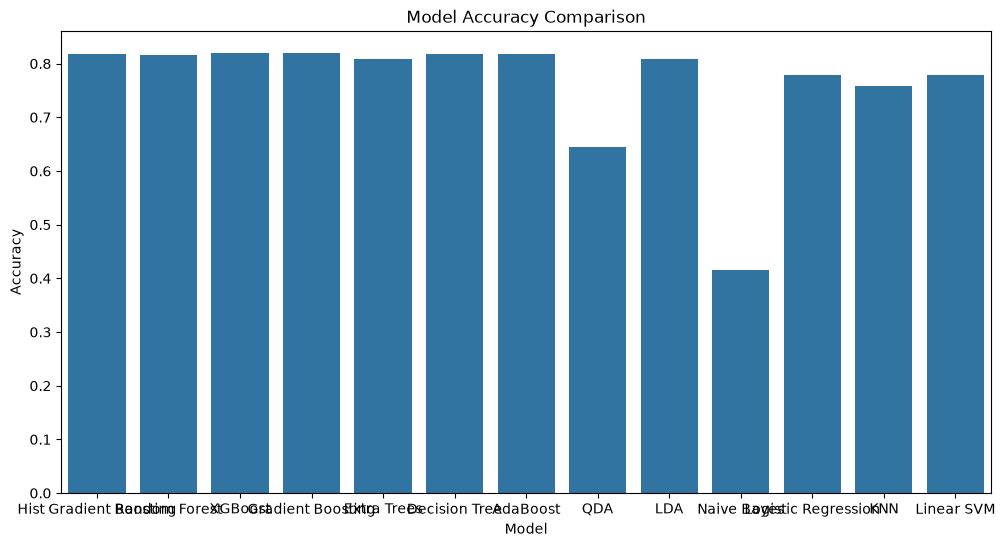

In [22]:
# accuracy comparison

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title('Model Accuracy Comparison')
plt.show()

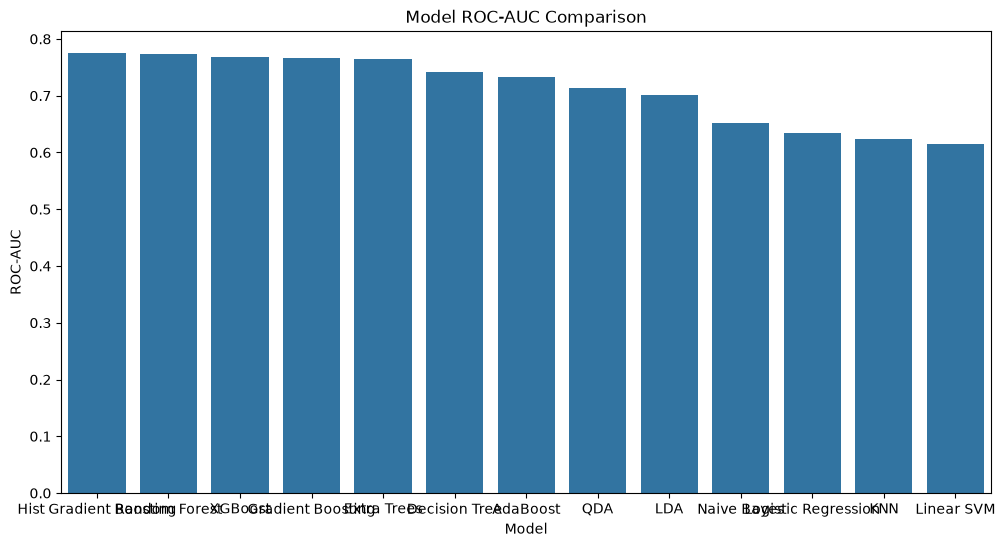

In [23]:
# ROC-AUC comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='ROC-AUC', data=results_df)
plt.title('Model ROC-AUC Comparison')
plt.show()

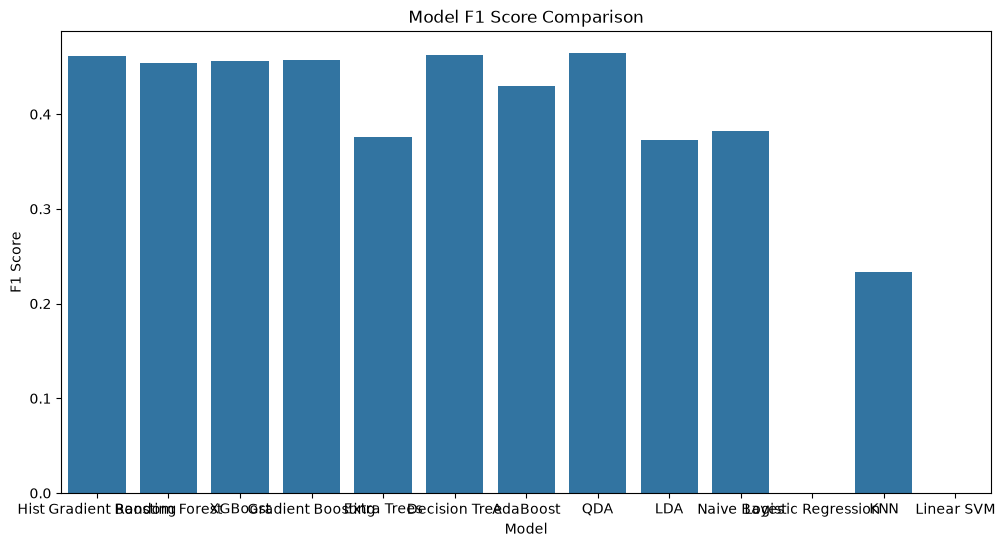

In [24]:
# F1 Score comparison

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='F1 Score', data=results_df)
plt.title('Model F1 Score Comparison')
plt.show()

In [25]:
# cross-validation of top models

top_3_models = results_df.head(3)["Model"].tolist()
print("Top 3 models:")
for model_name in top_3_models:
    print("_", model_name)

Top 3 models:
_ Hist Gradient Boosting
_ Random Forest
_ XGBoost


In [26]:
# stratified k-fold cross-validation for top models
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_results = []
for name in top_3_models:
    model = trained_models[name]
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": np.mean(scores),
        "Std ROC-AUC": np.std(scores)
    })
    print(
        f"{name}:"
        f"Mean ROC-AUC = {scores.mean():.4f},"
        f"Std = {scores.std():.4f}"
    )

Hist Gradient Boosting:Mean ROC-AUC = 0.8498,Std = 0.0063
Random Forest:Mean ROC-AUC = 0.8512,Std = 0.0027
XGBoost:Mean ROC-AUC = 0.8031,Std = 0.0059


In [27]:
# Cross-validation results comparison
cv_results_df = pd.DataFrame(
    cv_results,
    columns=["Model", "Mean ROC-AUC", "Std ROC-AUC"]
)

display(cv_results_df.style.format({
    "CV Mean ROC-AUC": "{:.4f}",
    "CV Std ROC-AUC": "{:.4f}"
}))

,Model,Mean ROC-AUC,Std ROC-AUC
0,Hist Gradient Boosting,0.849841,0.006321
1,Random Forest,0.851196,0.002675
2,XGBoost,0.803098,0.005949


In [28]:
# hyperparameter tuning for top model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_params = {
    'n_estimators': [30, 50, 70],
    'max_depth': [6,8,10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [29]:
# Randomised search for hyperparameter tuning

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_random.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [6, 8, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function wh

In [30]:
# best parameters and best score

print("Best parameters:")
print(rf_random.best_params_)
print("\nBest ROC-AUC score:", round(rf_random.best_score_, 4))

Best parameters:
{'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 10}

Best ROC-AUC score: 0.8605


In [31]:
# evaluate the tuned model on the test set

tuned_rf = rf_random.best_estimator_
rf_pred = tuned_rf.predict(X_test_scaled)
rf_prob = tuned_rf.predict_proba(X_test_scaled)[:, 1]
rf_acc = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_auc = roc_auc_score(y_test, rf_prob)
print("Tuned Random Forest")
print("Accuracy:", round(rf_acc, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1 Score:", round(rf_f1, 4))
print("ROC-AUC:", round(rf_auc, 4))

Tuned Random Forest
Accuracy: 0.791
Precision: 0.5279
Recall: 0.5207
F1 Score: 0.5243
ROC-AUC: 0.7605


In [32]:
# classificattion report
print(classification_report(y_test, rf_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87      4673
           1       0.53      0.52      0.52      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.69      0.70      6000
weighted avg       0.79      0.79      0.79      6000



In [33]:
# compare tuned random forest with other models

tuned_rf_row = pd.DataFrame({
        "Model": ["Tuned Random Forest"],
        "Accuracy": [rf_acc],
        "Precision": [rf_precision],
        "Recall": [rf_recall],
        "F1 Score": [rf_f1],
        "ROC-AUC": [rf_auc]
    })
final_results_df = pd.concat([results_df, tuned_rf_row], ignore_index=True)
final_results_df = final_results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
display(final_results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Hist Gradient Boosting,0.8182,0.6686,0.3527,0.4618,0.7751
1,Random Forest,0.8168,0.6662,0.3444,0.4540,0.7735
2,XGBoost,0.8190,0.6801,0.3429,0.4559,0.7674
3,Gradient Boosting,0.8197,0.6837,0.3436,0.4574,0.7668
4,Extra Trees,0.8077,0.6660,0.2615,0.3755,0.7648
5,Tuned Random Forest,0.7910,0.5279,0.5207,0.5243,0.7605
6,Decision Tree,0.8172,0.6615,0.3549,0.4620,0.7418
7,AdaBoost,0.8170,0.6918,0.3112,0.4293,0.7328
8,QDA,0.6453,0.3487,0.6956,0.4645,0.7137
9,LDA,0.8092,0.6827,0.2562,0.3726,0.7020


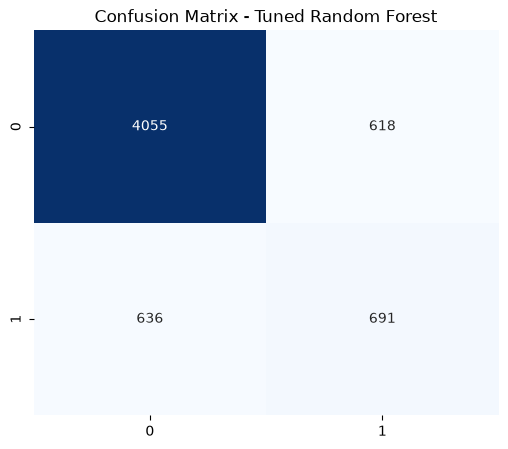

In [34]:
# Confusion matrix

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()

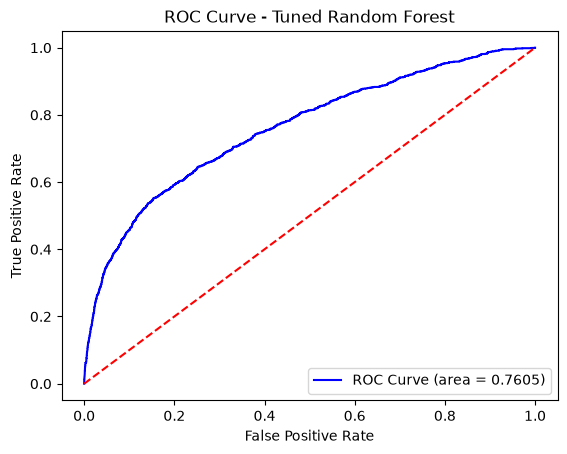

In [35]:
# roc_curve

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)
plt.Figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve (area = %0.4f)' % rf_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Random Forest')
plt.legend(loc="lower right")
plt.show()

In [36]:
# feature importance

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tuned_rf.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)
display(feature_importances.head(15))


,Feature,Importance
0,PAY_0,0.465036
1,LIMIT_BAL,0.148779
2,PAY_AMT2,0.068647
3,PAY_4,0.031438
4,BILL_AMT1,0.025747
5,PAY_AMT6,0.021721
6,PAY_AMT1,0.020973
7,AGE,0.020346
8,PAY_6,0.019164
9,PAY_3,0.018828


C:\Users\gargn\AppData\Local\Temp\ipykernel_32488\4182099990.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


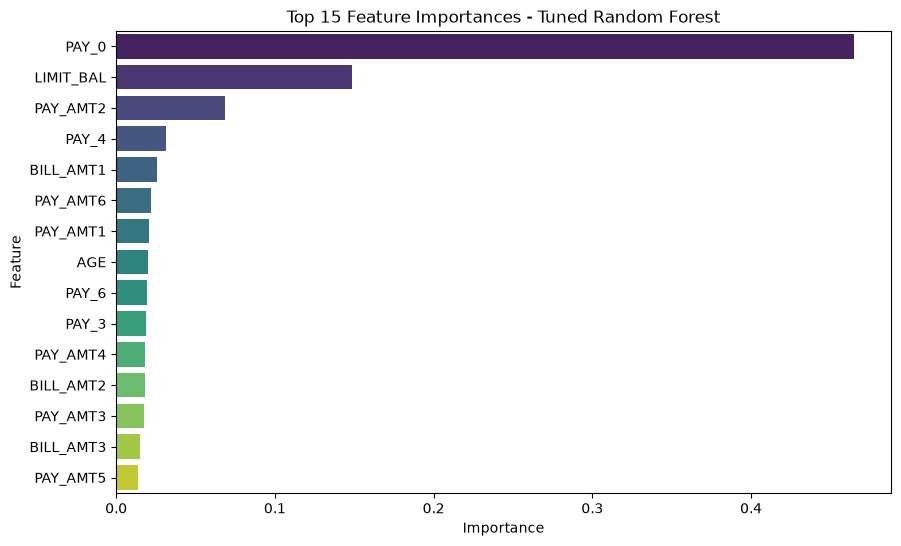

In [37]:
# Feature importance plotting

top_features = feature_importances.head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title('Top 15 Feature Importances - Tuned Random Forest')
plt.show()

In [38]:
# selecting final model

best_model = final_results_df.loc[final_results_df['ROC-AUC'].idxmax(), 'Model']
print("Best model based on ROC-AUC:", best_model)

Best model based on ROC-AUC: Hist Gradient Boosting


In [39]:
# selecting final model object
final_model = HistGradientBoostingClassifier(
    max_iter=50, 
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=42
)

X_train_smote_df = pd.DataFrame(X_train_smote, columns=X.columns)
final_model.fit(X_train_smote_df, y_train_smote)

print("Final model trained successfully")
print(final_model)


Final model trained successfully
HistGradientBoostingClassifier(learning_rate=0.05, max_iter=50,
                               max_leaf_nodes=15, random_state=42)


In [40]:
# Final test evaluation of the selected model

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)
final_pred = final_model.predict(X_test_scaled_df)
final_prob = final_model.predict_proba(X_test_scaled_df)[:,1]

final_acc = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred, zero_division=0)
final_recall = recall_score(y_test, final_pred, zero_division=0)
final_f1 = f1_score(y_test, final_pred, zero_division=0)
final_auc = roc_auc_score(y_test, final_prob)

print("\n" + "=" * 65)
print("CORRECTED FINAL MODEL PERFORMANCE")
print("=" * 65)

print("Final Model :", "Hist Gradient Boosting")
print("Accuracy    :", round(final_acc, 4))
print("Precision   :", round(final_precision, 4))
print("Recall      :", round(final_recall, 4))
print("F1 Score    :", round(final_f1, 4))
print("ROC-AUC     :", round(final_auc, 4))



CORRECTED FINAL MODEL PERFORMANCE
Final Model : Hist Gradient Boosting
Accuracy    : 0.7835
Precision   : 0.5099
Recall      : 0.5441
F1 Score    : 0.5264
ROC-AUC     : 0.7709


In [46]:
# Saving final model

import os
print("Models folder ready")

Models folder ready


In [47]:
# Saving final model

model_path = "credit_card_default_model.pkl"

import joblib
joblib.dump(
    final_model,
    model_path,
    compress=3
)
print("Final model saved successfully", model_path)

Final model saved successfully credit_card_default_model.pkl


In [48]:
# Saving scaler

scaler_path = "scaler.pkl"
joblib.dump(scaler, scaler_path, compress=3)
print("scaler saved successfully")

scaler saved successfully


In [50]:
# saving features names

feature_path ="feature_names.pkl"
joblib.dump(
    list(X.columns),
    feature_path,
    compress=3
)
print("features name saved successfully")

features name saved successfully


In [51]:
# saving model metadata

# Saving model metadata

metadata = {
    "model_name": best_model,
    "target": "default.payment.next.month",
    "number_of_features": len(X.columns),
    "smote_used": True,
    "scaling_used": True,
    "accuracy": float(final_acc),
    "precision": float(final_precision),
    "recall": float(final_recall),
    "f1_score": float(final_f1),
    "roc_auc": float(final_auc)
}

metadata_path = "model_metadata.pkl"

joblib.dump(
    metadata,
    metadata_path,
    compress=3
)

print("Model metadata saved successfully:", metadata_path)

Model metadata saved successfully: model_metadata.pkl
